In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

detecting lines

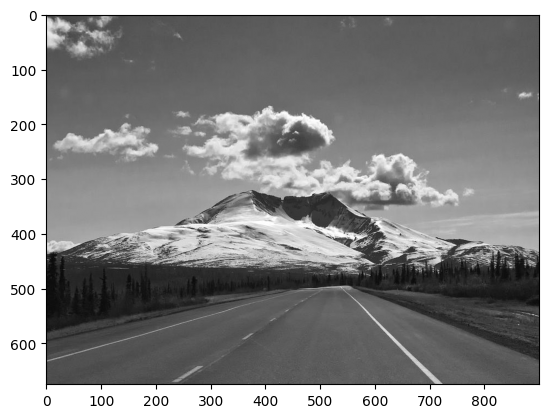

In [2]:
img = cv2.imread('road.jpg', 0)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

a little cheating :)

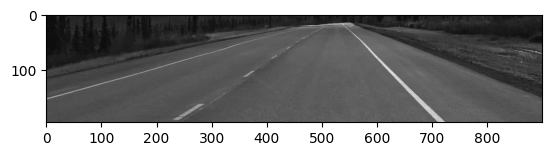

In [3]:
plt.imshow(img[480:, :], cmap='gray', vmin=0, vmax=255)

In [4]:
img = img[480:, :]

In [5]:
threshold1 = 100
threshold2 = 200

canny_edges = cv2.Canny(img, threshold1, threshold2)

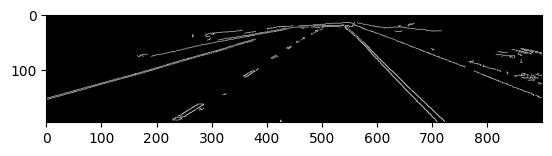

In [6]:
plt.imshow(canny_edges, cmap='gray', vmin=0, vmax=255)

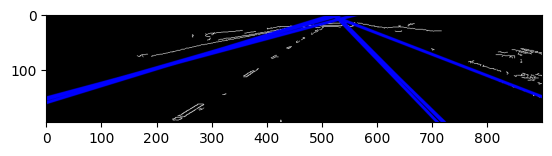

In [7]:
# Copy edges to the images that will display the results in BGR
cdst = cv2.cvtColor(canny_edges, cv2.COLOR_GRAY2BGR)

lines = cv2.HoughLines(canny_edges, 1, np.pi / 180, 150, None, 0, 0)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000 * (-b)), int(y0 + 1000 * (a)))
        pt2 = (int(x0 - 1000 * (-b)), int(y0 - 1000 * (a)))
        cv2.line(cdst, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

plt.imshow(cdst)